<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html week16.do.txt --no_mako -->
<!-- dom:TITLE: Quantum Computing, Quantum Machine Learning and Quantum Information Theories -->

# Quantum Computing, Quantum Machine Learning and Quantum Information Theories
**Morten Hjorth-Jensen**, Department of Physics, University of Oslo, Norway

Date: **May 14, 2025**

## Plan for the week of May 12-16
1. Quantum Boltzmann Machines: Theory and Implementation

  * Quantum neural networks, wrapping up discussions from last week (see notes from last week at <https://github.com/CompPhysics/QuantumComputingMachineLearning/blob/gh-pages/doc/pub/week15/ipynb/week15.ipynb>)

  * Classical Boltzmann  Machines (BMs)

  * Restricted Quantum Boltzmann Machines (RQBM)

  * Training Quantum Boltzmann Machines

  * Practical Implementation with PennyLane

2. Summary of course and work on  project 2

## Introduction

Quantum Boltzmann Machines (QBM extend the
classical Boltzmann machine (a probabilistic neural network) into the
quantum domain. QBMs promise richer representations by leveraging
quantum superposition and entanglement, potentially capturing
correlations that classical models cannot .

In these notes, we review
first classical Boltzmann machines and restricted Boltzmann machines (RBMs).
Thereafter we
introduce QBMs and their restricted variant (RQBM), discuss training
methods, and illustrate practical implementation using
PennyLane.

## Classical Boltzmann machines (aka Energy models)

We define a domain $\boldsymbol{X}$ of stochastic variables $\boldsymbol{X}= \{x_0,x_1, \dots , x_{n-1}\}$ with a pertinent probability distribution

$$
p(\boldsymbol{X})=\prod_{x_i\in \boldsymbol{X}}p(x_i),
$$

where we have assumed that the random varaibles $x_i$ are all independent and identically distributed (iid).

We will now assume that we can defined this function in terms of optimization parameters $\boldsymbol{\Theta}$, which could be the biases and weights of deep network, and a set of hidden variables we also assume to be random variables which also are iid. The domain of these variables is
$\boldsymbol{H}= \{h_0,h_1, \dots , h_{m-1}\}$.

## Probability model

We define a probability

$$
p(x_i,h_j;\boldsymbol{\Theta}) = \frac{f(x_i,h_j;\boldsymbol{\Theta})}{Z(\boldsymbol{\Theta})},
$$

where $f(x_i,h_j;\boldsymbol{\Theta})$ is a function which we assume is larger or
equal than zero and obeys all properties required for a probability
distribution and $Z(\boldsymbol{\Theta})$ is a normalization constant. Inspired by
statistical mechanics, we call it often for the partition function.
It is defined as (assuming that we have discrete probability distributions)

$$
Z(\boldsymbol{\Theta})=\sum_{x_i\in \boldsymbol{X}}\sum_{h_j\in \boldsymbol{H}} f(x_i,h_j;\boldsymbol{\Theta}).
$$

## Marginal and conditional probabilities

We can in turn define the marginal probabilities

$$
p(x_i;\boldsymbol{\Theta}) = \frac{\sum_{h_j\in \boldsymbol{H}}f(x_i,h_j;\boldsymbol{\Theta})}{Z(\boldsymbol{\Theta})},
$$

and

$$
p(h_i;\boldsymbol{\Theta}) = \frac{\sum_{x_i\in \boldsymbol{X}}f(x_i,h_j;\boldsymbol{\Theta})}{Z(\boldsymbol{\Theta})}.
$$

## Change of notation

**Note the change to a vector notation**. A variable like $\boldsymbol{x}$
represents now a specific **configuration**. We can generate an infinity
of such configurations. The final partition function is then the sum
over all such possible configurations, that is

$$
Z(\boldsymbol{\Theta})=\sum_{x_i\in \boldsymbol{X}}\sum_{h_j\in \boldsymbol{H}} f(x_i,h_j;\boldsymbol{\Theta}),
$$

changes to

$$
Z(\boldsymbol{\Theta})=\sum_{\boldsymbol{x}}\sum_{\boldsymbol{h}} f(\boldsymbol{x},\boldsymbol{h};\boldsymbol{\Theta}).
$$

If we have a binary set of variable $x_i$ and $h_j$ and $M$ values of $x_i$ and $N$ values of $h_j$ we have in total $2^M$ and $2^N$ possible $\boldsymbol{x}$ and $\boldsymbol{h}$ configurations, respectively.

We see that even for the modest binary case, we can easily approach a
number of configuration which is not possible to deal with.

## Optimization problem

At the end, we are not interested in the probabilities of the hidden variables. The probability we thus want to optimize is

$$
p(\boldsymbol{X};\boldsymbol{\Theta})=\prod_{x_i\in \boldsymbol{X}}p(x_i;\boldsymbol{\Theta})=\prod_{x_i\in \boldsymbol{X}}\left(\frac{\sum_{h_j\in \boldsymbol{H}}f(x_i,h_j;\boldsymbol{\Theta})}{Z(\boldsymbol{\Theta})}\right),
$$

which we rewrite as

$$
p(\boldsymbol{X};\boldsymbol{\Theta})=\frac{1}{Z(\boldsymbol{\Theta})}\prod_{x_i\in \boldsymbol{X}}\left(\sum_{h_j\in \boldsymbol{H}}f(x_i,h_j;\boldsymbol{\Theta})\right).
$$

## Further simplifications

We simplify further by rewriting it as

$$
p(\boldsymbol{X};\boldsymbol{\Theta})=\frac{1}{Z(\boldsymbol{\Theta})}\prod_{x_i\in \boldsymbol{X}}f(x_i;\boldsymbol{\Theta}),
$$

where we used $p(x_i;\boldsymbol{\Theta}) = \sum_{h_j\in \boldsymbol{H}}f(x_i,h_j;\boldsymbol{\Theta})$.
The optimization problem is then

$$
{\displaystyle \mathrm{arg} \hspace{0.1cm}\max_{\boldsymbol{\boldsymbol{\Theta}}\in {\mathbb{R}}^{p}}} \hspace{0.1cm}p(\boldsymbol{X};\boldsymbol{\Theta}).
$$

## Optimizing the logarithm instead

Computing the derivatives with respect to the parameters $\boldsymbol{\Theta}$ is
easier (and equivalent) with taking the logarithm of the
probability. We will thus optimize

$$
{\displaystyle \mathrm{arg} \hspace{0.1cm}\max_{\boldsymbol{\boldsymbol{\Theta}}\in {\mathbb{R}}^{p}}} \hspace{0.1cm}\log{p(\boldsymbol{X};\boldsymbol{\Theta})},
$$

which leads to

$$
\nabla_{\boldsymbol{\Theta}}\log{p(\boldsymbol{X};\boldsymbol{\Theta})}=0.
$$

## Expression for the gradients
This leads to the following equation

$$
\nabla_{\boldsymbol{\Theta}}\log{p(\boldsymbol{X};\boldsymbol{\Theta})}=\nabla_{\boldsymbol{\Theta}}\left(\sum_{x_i\in \boldsymbol{X}}\log{f(x_i;\boldsymbol{\Theta})}\right)-\nabla_{\boldsymbol{\Theta}}\log{Z(\boldsymbol{\Theta})}=0.
$$

The first term is called the positive phase and we assume that we have a model for the function $f$ from which we can sample values. Below we will develop an explicit model for this.
The second term is called the negative phase and is the one which leads to more difficulties.

## The derivative of the partition function

The partition function, defined above as

$$
Z(\boldsymbol{\Theta})=\sum_{x_i\in \boldsymbol{X}}\sum_{h_j\in \boldsymbol{H}} f(x_i,h_j;\boldsymbol{\Theta}),
$$

is in general the most problematic term. In principle both $x$ and $h$ can span large degrees of freedom, if not even infinitely many ones, and computing the partition function itself is often not desirable or even feasible. The above derivative of the partition function can however be written in terms of an expectation value which is in turn evaluated  using Monte Carlo sampling and the theory of Markov chains, popularly shortened to MCMC (or just MC$^2$).

## Explicit expression for the derivative
We can rewrite

$$
\nabla_{\boldsymbol{\Theta}}\log{Z(\boldsymbol{\Theta})}=\frac{\nabla_{\boldsymbol{\Theta}}Z(\boldsymbol{\Theta})}{Z(\boldsymbol{\Theta})},
$$

which reads in more detail

$$
\nabla_{\boldsymbol{\Theta}}\log{Z(\boldsymbol{\Theta})}=\frac{\nabla_{\boldsymbol{\Theta}} \sum_{x_i\in \boldsymbol{X}}f(x_i;\boldsymbol{\Theta})   }{Z(\boldsymbol{\Theta})}.
$$

We can rewrite the function $f$ (we have assumed that is larger or
equal than zero) as $f=\exp{\log{f}}$. We can then reqrite the last
equation as

$$
\nabla_{\boldsymbol{\Theta}}\log{Z(\boldsymbol{\Theta})}=\frac{ \sum_{x_i\in \boldsymbol{X}} \nabla_{\boldsymbol{\Theta}}\exp{\log{f(x_i;\boldsymbol{\Theta})}}   }{Z(\boldsymbol{\Theta})}.
$$

## Final expression

Taking the derivative gives us

$$
\nabla_{\boldsymbol{\Theta}}\log{Z(\boldsymbol{\Theta})}=\frac{ \sum_{x_i\in \boldsymbol{X}}f(x_i;\boldsymbol{\Theta}) \nabla_{\boldsymbol{\Theta}}\log{f(x_i;\boldsymbol{\Theta})}   }{Z(\boldsymbol{\Theta})},
$$

which is the expectation value of $\log{f}$

$$
\nabla_{\boldsymbol{\Theta}}\log{Z(\boldsymbol{\Theta})}=\sum_{x_i\in \boldsymbol{X}}p(x_i;\boldsymbol{\Theta}) \nabla_{\boldsymbol{\Theta}}\log{f(x_i;\boldsymbol{\Theta})},
$$

that is

$$
\nabla_{\boldsymbol{\Theta}}\log{Z(\boldsymbol{\Theta})}=\mathbb{E}(\log{f(x_i;\boldsymbol{\Theta})}).
$$

This quantity is evaluated using Monte Carlo sampling, with Gibbs
sampling as the standard sampling rule.  Before we discuss the
explicit algorithms, we need to remind ourselves about Markov chains
and sampling rules like the Metropolis-Hastings algorithm and Gibbs
sampling.

## Introducing the energy model

A typical Boltzmann machines employs a probability distribution

$$
p(\boldsymbol{x},\boldsymbol{h};\boldsymbol{\Theta}) = \frac{f(\boldsymbol{x},\boldsymbol{h};\boldsymbol{\Theta})}{Z(\boldsymbol{\Theta})},
$$

where $f(\boldsymbol{x},\boldsymbol{h};\boldsymbol{\Theta})$ is given by a so-called energy model. If we assume that the random variables $x_i$ and $h_j$ take binary values only, for example $x_i,h_j=\{0,1\}$, we have a so-called binary-binary model where

$$
f(\boldsymbol{x},\boldsymbol{h};\boldsymbol{\Theta})=-E(\boldsymbol{x}, \boldsymbol{h};\boldsymbol{\Theta}) = \sum_{x_i\in \boldsymbol{X}} x_i a_i+\sum_{h_j\in \boldsymbol{H}} b_j h_j + \sum_{x_i\in \boldsymbol{X},h_j\in\boldsymbol{H}} x_i w_{ij} h_j,
$$

where the set of parameters are given by the biases and weights $\boldsymbol{\Theta}=\{\boldsymbol{a},\boldsymbol{b},\boldsymbol{W}\}$.
**Note the vector notation** instead of $x_i$ and $h_j$ for $f$. The vectors $\boldsymbol{x}$ and $\boldsymbol{h}$ represent a specific instance of stochastic variables $x_i$ and $h_j$. These arrangements of $\boldsymbol{x}$ and $\boldsymbol{h}$ lead to a specific energy configuration.

## More compact notation

With the above definition we can write the probability as

$$
p(\boldsymbol{x},\boldsymbol{h};\boldsymbol{\Theta}) = \frac{\exp{(\boldsymbol{a}^T\boldsymbol{x}+\boldsymbol{b}^T\boldsymbol{h}+\boldsymbol{x}^T\boldsymbol{W}\boldsymbol{h})}}{Z(\boldsymbol{\Theta})},
$$

where the biases $\boldsymbol{a}$ and $\boldsymbol{h}$ and the weights defined by the matrix $\boldsymbol{W}$ are the parameters we need to optimize.

## Derivatives

Since the binary-binary energy model is linear in the parameters $a_i$, $b_j$ and
$w_{ij}$, it is easy to see that the derivatives with respect to the
various optimization parameters yield expressions used in the
evaluation of gradients like

$$
\frac{\partial E(\boldsymbol{x}, \boldsymbol{h};\boldsymbol{\Theta})}{\partial w_{ij}}=-x_ih_j,
$$

and

$$
\frac{\partial E(\boldsymbol{x}, \boldsymbol{h};\boldsymbol{\Theta})}{\partial a_i}=-x_i,
$$

and

$$
\frac{\partial E(\boldsymbol{x}, \boldsymbol{h};\boldsymbol{\Theta})}{\partial b_j}=-h_j.
$$

## Code example
Here we provide a simple Python code for a classical binary-binary Boltzmann applied to the MNIST data set.

Epoch 1: Reconstruction error = 43.9938
Epoch 2: Reconstruction error = 30.5684
Epoch 3: Reconstruction error = 27.5840
Epoch 4: Reconstruction error = 25.9388
Epoch 5: Reconstruction error = 24.8116
Epoch 6: Reconstruction error = 23.9585
Epoch 7: Reconstruction error = 23.3295
Epoch 8: Reconstruction error = 22.8396
Epoch 9: Reconstruction error = 22.4304
Epoch 10: Reconstruction error = 22.1022


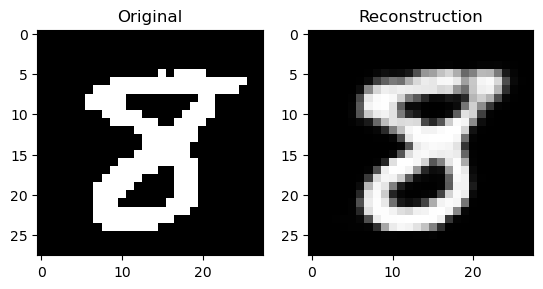

In [1]:
%matplotlib inline

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load and preprocess MNIST
def load_binarized_mnist():
    print("Downloading MNIST...")
    mnist = fetch_openml('mnist_784', version=1)
    X = mnist.data.astype(np.float32) / 255.0
    X = (X > 0.5).astype(np.float32)  # Binarize
    return X

class RBM:
    def __init__(self, n_visible, n_hidden, learning_rate=0.1):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate

        # Initialize weights and biases
        self.W = np.random.normal(0, 0.01, size=(n_visible, n_hidden))
        self.v_bias = np.zeros(n_visible)
        self.h_bias = np.zeros(n_hidden)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sample(self, probs):
        return (np.random.rand(*probs.shape) < probs).astype(np.float32)

    def train(self, data, epochs=10, batch_size=64):
        n_samples = data.shape[0]
        # Convert the DataFrame to a NumPy array to avoid the KeyError.
        data = data.to_numpy()  
        for epoch in range(epochs):
            np.random.shuffle(data)
            epoch_error = 0

            for i in range(0, n_samples, batch_size):
                v0 = data[i:i + batch_size]
                h0_prob = self.sigmoid(np.dot(v0, self.W) + self.h_bias)
                h0_sample = self.sample(h0_prob)

                v1_prob = self.sigmoid(np.dot(h0_sample, self.W.T) + self.v_bias)
                h1_prob = self.sigmoid(np.dot(v1_prob, self.W) + self.h_bias)

                # Weight and bias updates
                self.W += self.learning_rate * (np.dot(v0.T, h0_prob) - np.dot(v1_prob.T, h1_prob)) / batch_size
                self.v_bias += self.learning_rate * np.mean(v0 - v1_prob, axis=0)
                self.h_bias += self.learning_rate * np.mean(h0_prob - h1_prob, axis=0)

                epoch_error += np.mean((v0 - v1_prob) ** 2)

            print(f"Epoch {epoch + 1}: Reconstruction error = {epoch_error:.4f}")

    def reconstruct(self, v):
        h = self.sigmoid(np.dot(v, self.W) + self.h_bias)
        v_recon = self.sigmoid(np.dot(h, self.W.T) + self.v_bias)
        return v_recon

# Load and split MNIST
X = load_binarized_mnist()
X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)

# Initialize and train RBM
rbm = RBM(n_visible=784, n_hidden=128, learning_rate=0.1)
rbm.train(X_train, epochs=10, batch_size=64)

# Visualize reconstruction
def show_reconstruction(original, reconstructed):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(original.reshape(28, 28), cmap="gray")
    axes[0].set_title("Original")
    axes[1].imshow(reconstructed.reshape(28, 28), cmap="gray")
    axes[1].set_title("Reconstruction")
    plt.show()

sample = X_test.iloc[0].values # Access the first row and convert to NumPy array
reconstruction = rbm.reconstruct(sample[np.newaxis, :])
show_reconstruction(sample, reconstruction[0])

## Quantum Boltzmann Machines (QBMs)

A Quantum Boltzmann Machine (QBM) extends a classical BM by replacing
each binary unit with a qubit and generalizing the energy to a quantum
Hamiltonian.

Quantum Boltzmann machines (QBMs) generalize this framework by
encoding the model distribution in a quantum Gibbs state.  Instead of
a classical energy, one defines a Hamiltonian $H(\boldsymbol{\Theta})$
whose parameters $\boldsymbol{\Theta}$ (biases and couplings) play the
role of the RBM weights.  The model’s density operator is the state

$$
\rho(\boldsymbol{\theta}) = \frac{\exp{-(\beta H(\boldsymbol{\Theta}))}}{Z(\boldsymbol{\Theta})},
$$

with inverse temperature $\beta$ (set to 1 as we did for standard Boltzmann machines ) and partition function
$Z = Trace(\exp{-\beta H})$.  The probability of observing a visible
configuration v is obtained by measuring $\rho$ in the computational
basis (and tracing out hidden qubits if any).  In effect, the quantum
model can capture richer correlations via superposition and
entanglement.

## Quantum Boltzmann Machines

The model distribution over
classical bitstrings $v$ is given by the diagonal of the quantum Gibbs
state $\rho = e^{-H}/Z$.  A straightforward choice is a stoquastic
Hamiltonian that is diagonal in the computational basis
(e.g. involving only Pauli-$Z$ operators), which yields a probability
distribution very similar to a classical BM.  More generally one can
allow non-commuting terms (e.g. Pauli-$X$ fields) to introduce quantum
correlations .  In fact, Amin et al. (2018) introduced a QBM where the
training is done by bounding the quantum probabilities and sampling
from the transverse-field Ising Hamiltonian .  However,
non-commutativity makes exact training harder, so many proposals use
either special Hamiltonians or variational approximations.

## Restricted QBM (RQBM)

A Restricted Quantum Boltzmann Machine (RQBM) (also called Quantum RBM
or QRBM) enforces a bipartite structure analogous to the classical
RBM: no hidden-hidden interactions, and possibly limited
hidden-visible connectivity.  The simplest RQBM Hamiltonian can be
written (up to local Pauli bases) as

$$
H(\mathbf{a},\mathbf{b},W,V) \;=\; \sum_{i=1}^{n_v} a_i Z_i \;+\; \sum_{j=1}^{n_h} b_j Z_j \;+\; \sum_{i,j} W_{ij}\, Z_i Z_j \;+\; \sum_{i<i{\prime}} V_{ii{\prime}}\, Z_i Z_{i{\prime}} \,.
$$

Here $Z_i$ and $Z_j$ are Pauli-$Z$ operators on the visible and hidden
qubits respectively, $a_i,b_j$ are biases, $W_{ij}$ are visible-hidden
couplings, and V_{ii{\prime}} are possible visible-visible couplings.
(Classically, V=0 in an RBM; allowing V\neq0 gives a “2-local QRBM” as
in Wu et al. .)  Importantly, there are no hidden-hidden $ZZ$ terms in
this restricted model.  Equation xxxx  is a
direct quantum analogue of the RBM energy function, promoting it to an
operator acting on qubits.  Wu et al. (2020) used such a Hamiltonian
and proved that this 2-local QRBM is universal for quantum computation
.

## Quantum Statistical Mechanics Background

In quantum statistical mechanics, a system at inverse temperature
\beta is described by the density operator \rho = e^{-\beta H}/Z,
where the partition function \(Z = \Tr(e^{-\beta H})\) normalizes the
state.  For a qubit model we typically take \beta=1.  Observables are
expectation values \(\langle O\rangle = \Tr(\rho O)\). In the QBM
context, one is interested in the probability p(v) of measuring the
visible qubits in computational basis state v.  If the full thermal
state lives on both visible and hidden qubits, this probability is

$$
p_\theta(v) \;=\; \Tr\bigl[\Pi_v^{(\text{vis})}\,\rho(\theta)\bigr],
$$

where \(\Pi_v^{(\text{vis})}=|v\>\<v|\) acts on the visible subspace.
Equivalently, one may “trace out” the hidden qubits and work with the
reduced density matrix on the visible subsystem.  Computing these
probabilities requires preparing or approximating the Gibbs state of
H.  In practice this is done either by quantum simulators, quantum
annealers, or variational algorithms.

## Energy-Based Training Objective and Gradients

RQBM training is analogous to the classical case: we have a dataset of
bitstrings \{v^{(k)}\} from an unknown distribution p_{\rm data}(v).
The goal is to adjust the Hamiltonian parameters \theta so that the
model distribution \(p_\theta(v)=\<v|\rho(\theta)|v\>\) approximates
p_{\rm data}(v).  Equivalently, one can view the data distribution as
a target density matrix \eta (diagonal in the computational basis) and
minimize the quantum relative entropy (quantum KL divergence)

$$
S(\eta\Vert \rho(\theta)) = \Tr\!\bigl[\eta\ln\eta\bigr] - \Tr\!\bigl[\eta\ln\rho(\theta)\bigr] \;.
$$

## Non-negative loss
This loss is non-negative and equals zero only when \eta=\rho(\theta).
Writing \rho=e^{-H}/Z, one finds the gradient of the relative entropy
(for parameter \theta in H) as

$$
\frac{\partial}{\partial\theta} S(\eta\Vert\rho)
= \Tr\!\Bigl[\eta\,\partial_\theta(\beta H + \ln Z)\Bigr]
= \beta\Bigl(\Tr[\eta\,\partial_\theta H] - \Tr[\rho\,\partial_\theta H]\Bigr).
$$

In other words,

$$
\nabla_\theta S \;=\; \beta\Bigl(\langle \partial_\theta H\rangle_{\rm data} \;-\; \langle \partial_\theta H\rangle_{\rm model}\Bigr).
$$

## Analogy with classical RBM
This is directly analogous to the classical RBM gradient: the update
for each parameter is proportional to the difference between its
expectation under the data distribution and under the model’s Gibbs
distribution.  (Equation: $S(\eta\Vert\rho)={\rm Tr}[\eta\ln\eta]-{\rm
Tr}[\eta\ln\rho]$ .)  In practice, one computes $\langle
\partial_\theta H\rangle_{\rm data}$ by averaging over the training
set, and estimates $\langle \partial_\theta H\rangle_{\rm model}$ by
sampling from the quantum model.

## Gibbs sampling

Note that preparing exact Gibbs samples of a non-commuting Hamiltonian
is hard.  Many methods have been proposed to approximate the model
expectation.  For example, one may use a bound on the quantum free
energy (as in Amin et al. ), or perform contrastive divergence with a
quantum device.  Recent theoretical work shows that minimizing the
relative entropy in QBM training can be done with stochastic gradient
descent in polynomial sample complexity under reasonable assumptions .

## Parameter Optimization and Variational Techniques

Given the gradient above, one can optimize \theta by standard
gradient-based methods (SGD, Adam, etc.).  In a gate-based setting, we
implement the RQBM Hamiltonian via a parameterized quantum circuit
(ansatz) and use variational quantum algorithms (VQAs).  Each
parameter in H is encoded as a gate angle or circuit parameter.  The
gradient of a circuit expectation can be obtained by the
parameter-shift rule or automatic differentiation.

One approach is the $\beta$-Variational Quantum Eigensolver (β-VQE)
technique.  Liu et al. (2021) proposed a variational ansatz to
represent a thermal (mixed) state using a combination of a classical
neural network and a quantum circuit.  Huijgen et al. (2024) applied
this to QBM training: an inner loop runs β-VQE to approximate the
Gibbs state of H(\theta), while an outer loop updates \theta to
minimize the relative entropy to the data .  This “nested loop”
algorithm effectively sidesteps direct sampling of the true quantum
Boltzmann state by variational approximation.  It has been shown to
work on both classical and quantum target data, achieving
high-fidelity learning for up to 10 qubits .

Other sophisticated ansätze exist.  For example, Evolved Quantum
Boltzmann Machines (Minervini et al., 2025) prepare a thermal state
under one Hamiltonian and then evolve it under another, combining
imaginary- and real-time evolution.  They derive analytical gradient
formulas and propose natural-gradient variants .  There are also
“semi-quantum” RBMs (sqRBMs) which commute in the visible subspace and
treat the hidden units quantum-mechanically.  Intriguingly, sqRBMs
were found to be expressively equivalent to classical RBMs, requiring
fewer hidden units for the same number of parameters . In practice,
however, variational optimization in high dimensions can suffer from
barren plateaus. Recent analysis shows that training QBMs using the
relative entropy objective avoids many of these concentration issues,
with provably polynomial complexity under realistic conditions .

## Implementation with PennyLane

As a concrete example, we outline how to implement an RQBM in
PennyLane. We consider n_v visible and n_h hidden qubits. The ansatz
can be, for instance, layers of parameterized single-qubit rotations
and entangling gates that respect the bipartite structure.  Below is
illustrative code (in Python) using PennyLane’s default.qubit
simulator.

<!-- !bc pycod -->

<!-- !ec -->

This circuit takes a parameter vector params of length n_v+n_h and
returns the probabilities q_\theta(v) of measuring each visible
bitstring v.  Notice we measure only the visible wires (the
wires=list(range(n_v)) in qml.probs marginalizes out the hidden
qubit).

Next, we train this model to match a target dataset distribution.
Suppose our data has distribution target = [p(00), p(01), p(10),
p(11)].  We can define the (classical) loss as the Kullback-Leibler
divergence D_{\rm KL}(p_{\rm data}\Vert q_\theta) or simply the
negative log-likelihood.  Then we update params by gradient descent.
PennyLane’s automatic differentiation can compute gradients via the
parameter-shift rule, but we show an explicit parameter-shift
computation for demonstration:

In [2]:
Initialize parameters and perform a simple gradient descent

This code illustrates the training loop.  At each epoch we evaluate
the loss, compute gradients (via two forward passes per parameter),
and update the parameters.  In practice one can use qml.grad for
automatic gradients, and more sophisticated optimizers (Adam, natural
gradient, etc.). The above shows that PennyLane can seamlessly
integrate quantum circuit definitions with classical training logic.

$$
H = -\sum_{a=1}^N \Gamma_a,\sigma^x_a ;-;\sum_{a=1}^N b_a,\sigma^z_a ;-;\sum_{a<b} u_{ab},\sigma^z_a \sigma^z_b,
$$

where $\sigma_a^x,\sigma_a^z$ are the Pauli matrices on qubit $a$,
$\Gamma_a$ is a “transverse” field, $b_a$ are local fields (biases),
and $u_{ab}$ are interaction strengths .  Here each qubit can be
interpreted analogously to a classical unit, but the $\sigma^x$ term
induces quantum superposition.  One can also include $\sigma^y$ or
more complex terms, but we focus on this common ansatz.

## Code 1

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load and binarize MNIST
def load_binarized_mnist():
    print("Downloading MNIST...")
    mnist = fetch_openml('mnist_784', version=1)
    X = mnist.data.astype(np.float32) / 255.0
    X = (X > 0.5).astype(np.float32)  # Binarize
    return X

class RBM:
    def __init__(self, n_visible, n_hidden, learning_rate=0.1):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate

        # Parameters
        self.W = np.random.normal(0, 0.01, size=(n_visible, n_hidden))
        self.v_bias = np.zeros(n_visible)
        self.h_bias = np.zeros(n_hidden)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sample(self, probs):
        return (np.random.rand(*probs.shape) < probs).astype(np.float32)

    def train(self, data, epochs=10, batch_size=64):
        # Convert the DataFrame to a NumPy array with reset indices to avoid the KeyError.
        data = data.reset_index(drop=True).to_numpy() 
        
        n_samples = data.shape[0]

        for epoch in range(epochs):
            np.random.shuffle(data) # Now shuffles the NumPy array with default integer indices
            epoch_error = 0
    

            for i in range(0, n_samples, batch_size):
                v0 = data[i:i + batch_size]
                h0_prob = self.sigmoid(np.dot(v0, self.W) + self.h_bias)
                h0_sample = self.sample(h0_prob)

                # Gibbs step
                v1_prob = self.sigmoid(np.dot(h0_sample, self.W.T) + self.v_bias)
                v1_sample = self.sample(v1_prob)
                h1_prob = self.sigmoid(np.dot(v1_sample, self.W) + self.h_bias)

                # Update
                self.W += self.learning_rate * (np.dot(v0.T, h0_prob) - np.dot(v1_sample.T, h1_prob)) / batch_size
                self.v_bias += self.learning_rate * np.mean(v0 - v1_sample, axis=0)
                self.h_bias += self.learning_rate * np.mean(h0_prob - h1_prob, axis=0)

                epoch_error += np.mean((v0 - v1_sample) ** 2)

            print(f"Epoch {epoch + 1}: Reconstruction error = {epoch_error:.4f}")

    def gibbs_sample(self, v_start, k=1):
        """Perform k steps of Gibbs sampling starting from visible vector v_start"""
        v = v_start.copy()
        for _ in range(k):
            h_prob = self.sigmoid(np.dot(v, self.W) + self.h_bias)
            h = self.sample(h_prob)
            v_prob = self.sigmoid(np.dot(h, self.W.T) + self.v_bias)
            v = self.sample(v_prob)
        return v

    def generate(self, n_samples=10, k=100):
        """Generate new samples via Gibbs sampling from random initial states"""
        samples = []
        for _ in range(n_samples):
            v_start = np.random.randint(0, 2, size=(1, self.n_visible)).astype(np.float32)
            v_sample = self.gibbs_sample(v_start, k=k)
            samples.append(v_sample[0])
        return np.array(samples)

# Load and split MNIST
X = load_binarized_mnist()
X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)

# Train RBM
rbm = RBM(n_visible=784, n_hidden=128, learning_rate=0.1)
rbm.train(X_train, epochs=10, batch_size=64)

# Generate digits
generated_digits = rbm.generate(n_samples=10, k=200)

# Display generated digits
def show_generated(images):
    fig, axes = plt.subplots(1, len(images), figsize=(15, 2))
    for ax, img in zip(axes, images):
        ax.imshow(img.reshape(28, 28), cmap="gray")
        ax.axis("off")
    plt.suptitle("Generated Digits from RBM via Gibbs Sampling")
    plt.show()

show_generated(generated_digits)

Epoch 1: Reconstruction error = 99.7773
Epoch 2: Reconstruction error = 70.3592
Epoch 3: Reconstruction error = 63.0659
Epoch 4: Reconstruction error = 58.9772
Epoch 5: Reconstruction error = 56.1171
Epoch 6: Reconstruction error = 53.9727
Epoch 7: Reconstruction error = 52.2405
Epoch 8: Reconstruction error = 50.9137
Epoch 9: Reconstruction error = 49.7247


## Code 2

In [4]:
import pennylane as qml
from pennylane import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load and binarize MNIST
def load_binarized_mnist(n_samples=1000):
    print("Downloading MNIST...")
    mnist = fetch_openml('mnist_784', version=1)
    X = mnist.data[:n_samples].astype(np.float32) / 255.0
    X = (X > 0.5).astype(np.float32)
    return X

# Quantum device and number of hidden qubits
n_visible = 8  # We will use only 8 pixels for this toy example
n_hidden = 4
dev = qml.device("default.qubit", wires=n_hidden)

# Define quantum circuit as hidden layer
def qrbm_circuit(v, weights):
    for i in range(n_hidden):
        qml.Hadamard(wires=i)
        qml.RZ(weights[i], wires=i)
    for i in range(n_hidden - 1):
        qml.CNOT(wires=[i, i + 1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_hidden)]

# QRBM class
class QRBM:
    def __init__(self, n_visible, n_hidden, lr=0.1):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.weights = np.random.uniform(0, 2 * np.pi, n_hidden, requires_grad=True)
        self.visible_bias = np.zeros(n_visible, requires_grad=False)
        self.optimizer = qml.GradientDescentOptimizer(stepsize=lr)

    def reconstruct(self, v):
        # Use quantum circuit to sample hidden state
        h_exp = hidden_layer(v, self.weights)
        v_recon = np.tanh(np.dot(h_exp, np.random.randn(self.n_hidden, self.n_visible)) + self.visible_bias)
        return (v_recon > 0.5).astype(np.float32)

    def cost(self, v):
        recon = self.reconstruct(v)
        return np.mean((v - recon) ** 2)

    def train(self, data, epochs=10):
        for epoch in range(epochs):
            total_cost = 0
            for v in data:
                v = v[:self.n_visible]
                self.weights, cost_val = self.optimizer.step_and_cost(lambda w: self.cost(v), self.weights)
                total_cost += cost_val
            print(f"Epoch {epoch+1}: Cost = {total_cost / len(data):.4f}")
# Load and reduce MNIST
X = load_binarized_mnist(n_samples=500)
X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)

# Train QRBM
qrbm = QRBM(n_visible=n_visible, n_hidden=n_hidden, lr=0.3)
# Convert X_train to a NumPy array before training
qrbm.train(X_train.to_numpy(), epochs=10) # Converting X_train to numpy array

# Visualize a reconstruction
def show_reconstruction(original, reconstructed):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(original[:n_visible].reshape(1, -1), cmap="gray", aspect='auto')
    axes[0].set_title("Original")
    axes[1].imshow(reconstructed.reshape(1, -1), cmap="gray", aspect='auto')
    axes[1].set_title("Reconstruction")
    plt.show()

# Access the first row using .iloc to avoid the KeyError
sample = X_test.iloc[0].values # Access the first row and convert to NumPy array
reconstruction = qrbm.reconstruct(sample[:n_visible])
show_reconstruction(sample, reconstruction)